In [9]:
from langchain_community.document_loaders import TextLoader
from langchain_huggingface import HuggingFaceEndpointEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import  FAISS
from pydantic import BaseModel
from langchain_core.documents import Document
from langchain_groq import ChatGroq


In [5]:
loader=TextLoader("../resourse/research_notes.txt",encoding="utf-8").load()
chunks=RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50).split_documents(loader)

embeddings=HuggingFaceEndpointEmbeddings(
    repo_id="sentence-transformers/all-MiniLM-L6-v2",
    task="feature-extraction"
)
store=FAISS.from_documents(chunks,embeddings)
retriever=store.as_retriever()
retriever


/media/shaymaa/New Volume/AI udemy/AgenticAIworkspace/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEndpointEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x7f422e3f5a60>, search_kwargs={})

In [12]:
import os 
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm=ChatGroq(model="llama-3.3-70b-versatile")

In [18]:
class State(BaseModel):
    question:str
    sub_list:list[str]=[]
    retrieved_docs:list[Document]=[]
    answer:str=""


In [19]:
def planning(state:State) -> State:
    prompt=f"break the question in 2-3 reasoning question /n/n {state.question} "
    response=llm.invoke(prompt).content
    seq=[line for line in response.split("\n") if line.strip()]
    return state.model_copy(update={"sub_list":seq})
    
    

In [20]:
def retieve_per_step(state:State) -> State:
    all_docs=[]
    for sub in state.sub_list:
        doc=retriever.invoke(sub)
        all_docs.extend(doc)

    return state.model_copy(update={"retrieved_docs":all_docs})

In [24]:
def generate_answer(state:State) -> State:
    context="/n/n".join(doc.page_content for doc in state.retrieved_docs)
    prompt = f"""
You are answering a complex question using reasoning and retrieved documents.

Question: {state.question}

Relevant Information:
{context}

Now synthesize a well-reasoned final answer.
"""
    answer=llm.invoke(prompt).content.strip()
    return state.model_copy(update={"answer":answer})

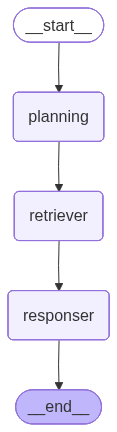

In [25]:
from langgraph.graph import StateGraph,END

graph=StateGraph(State)

graph.add_node("planning",planning)
graph.add_node("retriever",retieve_per_step)
graph.add_node("responser",generate_answer)

graph.set_entry_point("planning")
graph.add_edge("planning","retriever")
graph.add_edge("retriever","responser")
graph.add_edge("responser",END)

builder=graph.compile()
builder

In [27]:
question="what is the ai agents?"
state=State(question=question)
final_response=builder.invoke(state)
print(final_response['sub_list'])
print("final answer",final_response["answer"])

['To break down the question "What is AI agents?" into 2-3 reasoning questions, we can consider the following:', '1. **What is the definition of AI agents?**', '   - This question seeks to understand the basic concept of AI agents, including what they are designed to do and how they operate. It involves looking into the fundamental characteristics that define AI agents, such as their ability to perceive their environment, reason about what they perceive, and take actions to achieve specific goals.', '2. **How do AI agents interact with their environment?**', "   - This reasoning question delves into the operational aspects of AI agents, including how they sense their surroundings, the types of actions they can perform, and how they adapt to changes in their environment. It also involves understanding the feedback loop between an AI agent's actions and the responses it receives from the environment.", '3. **What are the applications and implications of AI agents?**', '   - This question